<a href="https://colab.research.google.com/github/aopsuser/Midterm1_Insurance_Project/blob/main/Meirim_Midterm1_Insurance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Деректерді жүктеу


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



 2. Бос мәндерді талдау
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 Датасетте бос мәндер жоқ. Бос мәндер графигі қажет емес.

 EDA графиктерін салу


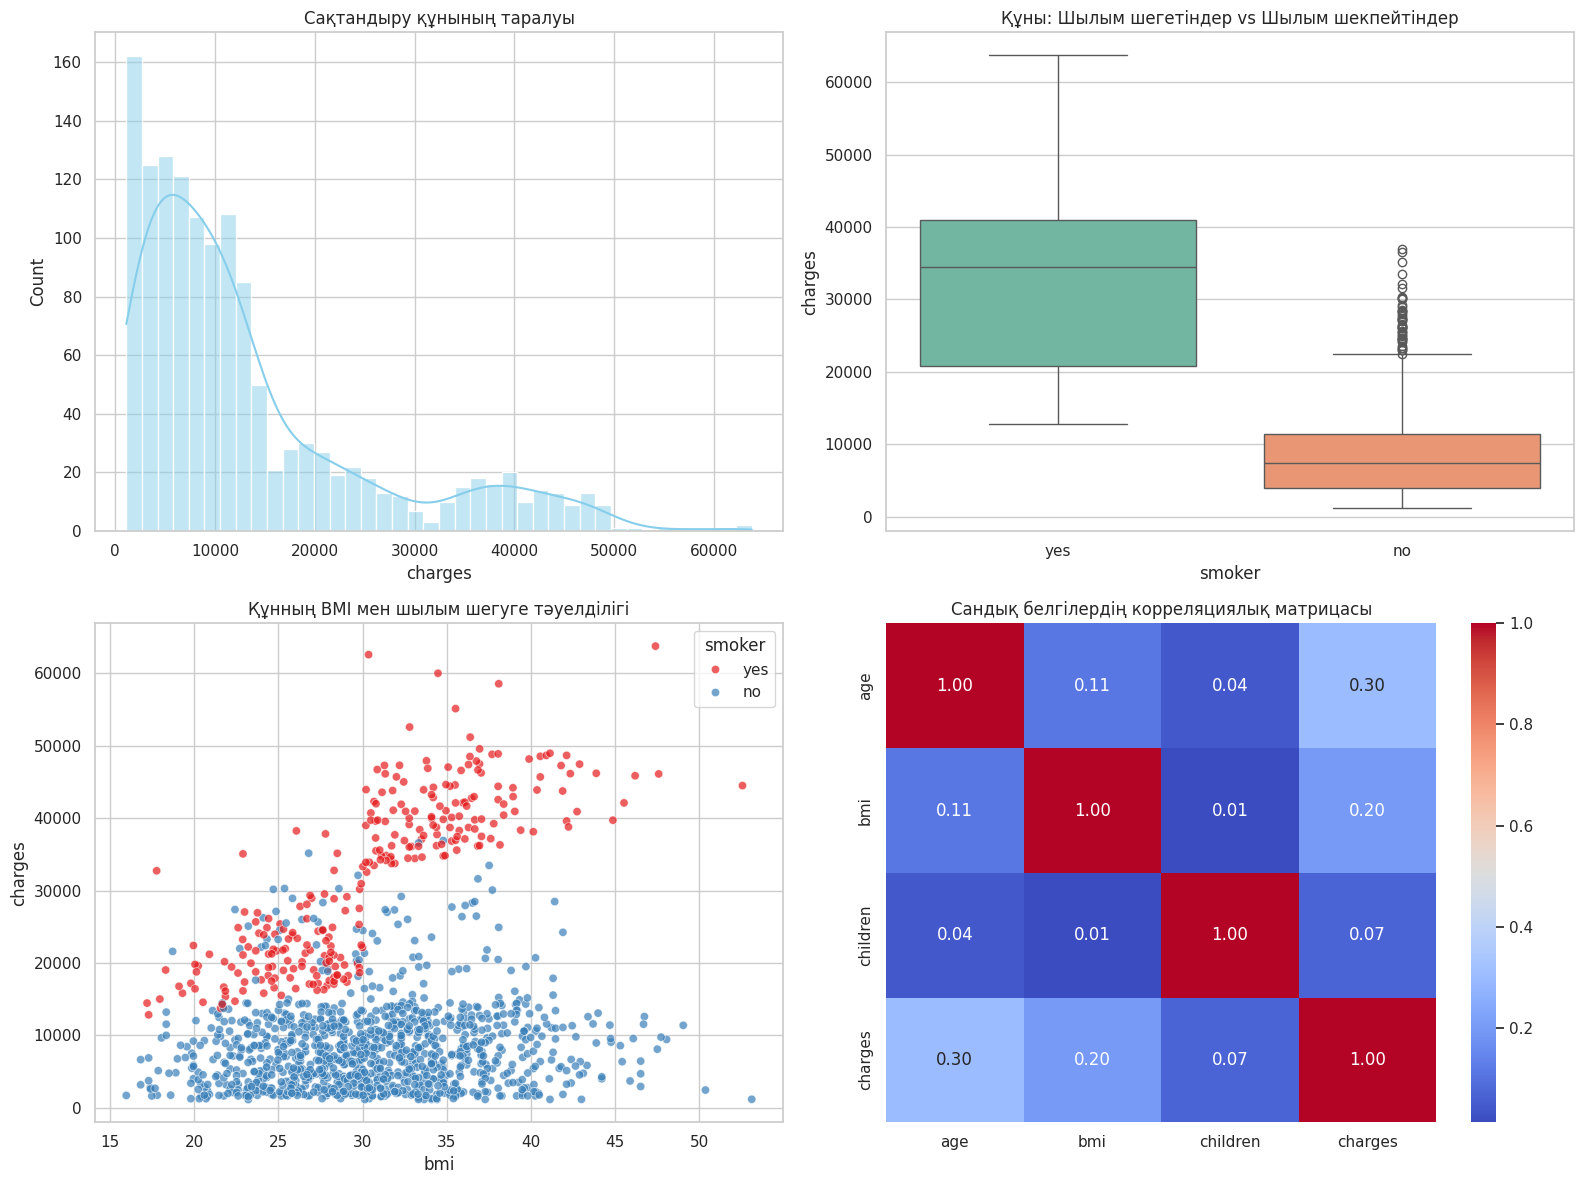


 3. Нәтижелер 
--- Linear Regression (Сызықтық регрессия) ---
MAE: 4181.19
RMSE: 5796.28
R2 Score: 0.7836

--- Random Forest (Кездейсоқ орман) ---
MAE: 2543.98
RMSE: 4567.78
R2 Score: 0.8656



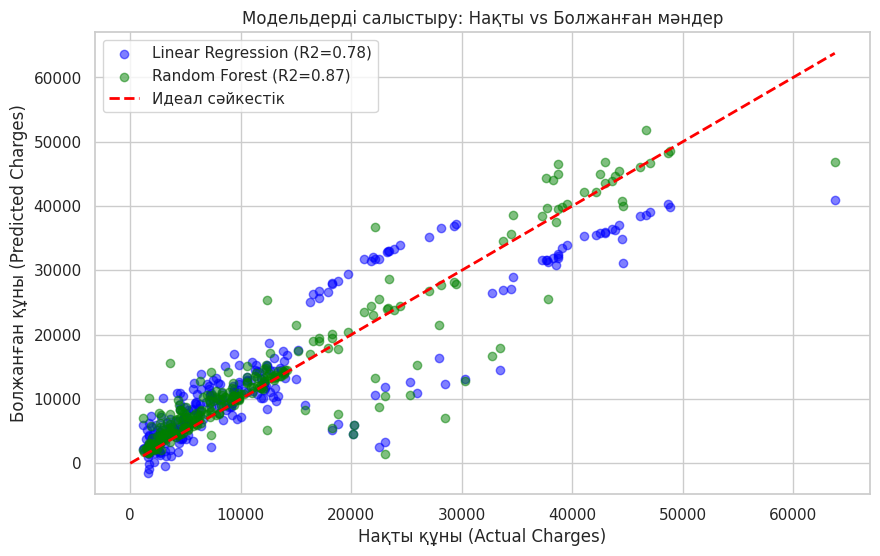

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("1. Деректерді жүктеу")
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
display(df.head()) if 'get_ipython' in globals() else print(df.head())

print("\n 2. Бос мәндерді талдау")
missing_values = df.isnull().sum()
print(missing_values)

missing_to_plot = missing_values[missing_values > 0]
if not missing_to_plot.empty:
    missing_to_plot.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Бағандар бойынша бос мәндер саны')
    plt.xlabel('Бағандар')
    plt.show()
else:
    print("\n Датасетте бос мәндер жоқ. Бос мәндер графигі қажет емес.")

print("\n EDA графиктерін салу")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['charges'], bins=40, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Сақтандыру құнының таралуы')

sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Құны: Шылым шегетіндер vs Шылым шекпейтіндер')

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Құнның BMI мен шылым шегуге тәуелділігі')

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Сандық белгілердің корреляциялық матрицасы')

plt.tight_layout()
plt.show()

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rf_pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

def print_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}\n")

print("\n 3. Нәтижелер ")
print_metrics(y_test, y_pred_lr, "Linear Regression (Сызықтық регрессия)")
print_metrics(y_test, y_pred_rf, "Random Forest (Кездейсоқ орман)")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue', label=f'Linear Regression (R2={r2_score(y_test, y_pred_lr):.2f})')
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green', label=f'Random Forest (R2={r2_score(y_test, y_pred_rf):.2f})')
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--', linewidth=2, label='Идеал сәйкестік')
plt.xlabel('Нақты құны (Actual Charges)')
plt.ylabel('Болжанған құны (Predicted Charges)')
plt.title('Модельдерді салыстыру: Нақты vs Болжанған мәндер')
plt.legend()
plt.show()